# Example: Buoyancy-driven Flow in a Cavity

Consider the following configuration: 
* All four walls are stationary with no-slip conditions ($u = 0, v = 0$).
* Temperature:
    * Left wall ($x = 0$): Fixed cold temperature ($T = T_\text{h}$).
    * Right wall ($x = L$): Fixed hot temperature ($T = T_\text{c}$).
    * Top and Bottom walls ($y = 0, y = H$): Insulated/Adiabatic ($\frac{\partial T}{\partial y} = 0$).

Key assumptions:
* **Incompressible Boussinesq Approximation**: Density $\rho$ is constant in the continuity and momentum equations, except in the vertical buoyancy body force term, modeled as $g \beta (T - T_0)$.
* **Uniform Fluid Properties**: Kinematic viscosity $\nu$, thermal diffusivity $\alpha = k / (\rho c_p)$, and thermal expansion coefficient $\beta$ remain constant.
* **Simplified Thermal Energy Balance**: Viscous dissipation ($\Phi = 0$), pressure work ($Dp/Dt = 0$), and volumetric heat generation ($q''' = 0$) are neglected.
* **Collocated Grid Scheme**: All flow variables ($u, v, p, T$) reside at identical grid points $(i,j)$.

Starting from the simplified first law of thermodynamics $\rho c_p \frac{DT}{Dt} = k \nabla^2 T$, the 2D energy equation expands to:

$$\frac{\partial T}{\partial t} + u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right)$$

Spatial derivatives are approximated using 2nd-order central differences (`dTdx`, `dTdy`, `dTdx2`, `dTdy2`):

$$\left. \frac{\partial T}{\partial x} \right\vert{}_{i,j}^n \approx \frac{T_{i,j+1}^n - T_{i,j-1}^n}{2\Delta x}, \quad \left. \frac{\partial^2 T}{\partial x^2} \right\vert{}_{i,j}^n \approx \frac{T_{i,j+1}^n - 2T_{i,j}^n + T_{i,j-1}^n}{\Delta x^2}$$


An explicit time step advances the temperature array `T[1:-1, 1:-1]`:


$$T_{i,j}^{n+1} = T_{i,j}^n + \Delta t \left( - u_{i,j}^n \left. \frac{\partial T}{\partial x} \right\vert{}_{i,j}^n - v_{i,j}^n \left. \frac{\partial T}{\partial y} \right\vert{}_{i,j}^n + \alpha \left( \left. \frac{\partial^2 T}{\partial x^2} \right\vert{}_{i,j}^n + \left. \frac{\partial^2 T}{\partial y^2} \right\vert{}_{i,j}^n \right) \right)$$

Recall that we use an intermediate velocity prediction, ($u^*, v^*$). The non-conservative 2D Navier-Stokes momentum equations including Boussinesq buoyancy are:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

$$\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right) + g \beta (T - T_0)$$


Omitting pressure terms yields intermediate predictor velocities `u_star` and `v_star`:


$$u_{i,j}^* = u_{i,j}^n + \Delta t \left( - u \frac{\partial u}{\partial x} - v \frac{\partial u}{\partial y} + \nu \nabla^2 u \right)_{i,j}^n$$

$$v_{i,j}^* = v_{i,j}^n + \Delta t \left( - u \frac{\partial v}{\partial x} - v \frac{\partial v}{\partial y} + \nu \nabla^2 v + g \beta (T_{i,j}^{n+1} - T_0) \right)_{i,j}^n$$

Recall that we also need to use a Poisson solver to determine pressure, since the flow is incompressible and we lack a transport equation for pressure. Enforcing mass conservation $\nabla \cdot \mathbf{u}^{n+1} = 0$ through velocity correction $\mathbf{u}^{n+1} = \mathbf{u}^* - \frac{\Delta t}{\rho} \nabla p^{n+1}$ yields the Poisson equation:


$$\nabla^2 p^{n+1} = \frac{\rho}{\Delta t} (\nabla \cdot \mathbf{u}^*) = b_{i,j}$$


The code computes source term `b` via central differences:


$$b_{i,j} = \frac{\rho}{\Delta t} \left( \frac{u_{i,j+1}^* - u_{i,j-1}^*}{2\Delta x} + \frac{v_{i+1,j}^* - v_{i-1,j}^*}{2\Delta y} \right)$$


The 5-point discrete Laplacian $\nabla^2 p = b$ is solved over `nit` inner relaxation steps:


$$p_{i,j}^{(k+1)} = \frac{(p_{i,j+1}^{(k)} + p_{i,j-1}^{(k)})\Delta y^2 + (p_{i+1,j}^{(k)} + p_{i-1,j}^{(k)})\Delta x^2 - b_{i,j}\Delta x^2 \Delta y^2}{2(\Delta x^2 + \Delta y^2)}$$

Finally, true velocities `u` and `v` at step $n+1$ are updated using discrete pressure gradients:


$$u_{i,j}^{n+1} = u_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i,j+1}^{n+1} - p_{i,j-1}^{n+1}}{2\Delta x} \right)$$

$$v_{i,j}^{n+1} = v_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i+1,j}^{n+1} - p_{i-1,j}^{n+1}}{2\Delta y} \right)$$

## Appendix A: Dimensionless Groups
The Prandtl number is the ratio of momentum diffusivity (kinematic viscosity) to thermal diffusivity:

$$Pr = \frac{\nu}{\alpha}$$

where $\nu$ is kinematic viscosity ($m^2/s$), representing the rate of momentum transport and $\alpha$ is thermal diffusivity ($m^2/s$), representing the rate of heat transport. It quantifies the relative thickness of the momentum boundary layer compared to the thermal boundary layer. For example, $Pr \approx 0.71$ for air (thermal boundary layer is thicker), while $Pr \approx 7$ for water at room temperature.

The Rayleigh number measures the ratio of buoyancy forces driving the flow to the resisting viscous drag and thermal dissipation forces:

$$Ra = \frac{g \beta (T_h - T_c) L^3}{\nu \alpha}$$

where $g$ is the acceleration due to gravity ($m/s^2$), $\beta$ is the volumetric thermal expansion coefficient ($1/K$), $T_h - T_c$ is the temperature differential across the cavity ($\Delta T$), and $L$ is the characteristic scale of the cavity ($m$). It determines the primary mode of heat transfer. Below a critical value ($Ra_c \approx 10^3$), heat transfers mostly via conduction. Above $Ra_c$, buoyancy forces overcome viscous drag, initiating natural convection currents.

If we scale the variables above using a characteristic length $L$, thermal diffusion velocity $U_0 = \frac{\alpha}{L}$, time scale $t_0 = \frac{L^2}{\alpha}$, and dimensionless temperature $\theta = \frac{T - T_0}{T_h - T_c}$, we can transform our governing equations to non-dimensional form. First we have our energy equation:

$$\frac{\partial \theta}{\partial t^*} + u^* \frac{\partial \theta}{\partial x^*} + v^* \frac{\partial \theta}{\partial y^*} = \frac{\partial^2 \theta}{\partial {x^*}^2} + \frac{\partial^2 \theta}{\partial {y^*}^2}$$

The dimensionless form of the $x$-momentum equation is:

$$\frac{\partial u^*}{\partial t^*} + u^* \frac{\partial u^*}{\partial x^*} + v^* \frac{\partial u^*}{\partial y^*} = -\frac{\partial p^*}{\partial x^*} + Pr \left( \frac{\partial^2 u^*}{\partial {x^*}^2} + \frac{\partial^2 u^*}{\partial {y^*}^2} \right)$$

The dimensionless form of the $y$-momentum equation is:

$$\frac{\partial v^*}{\partial t^*} + u^* \frac{\partial v^*}{\partial x^*} + v^* \frac{\partial v^*}{\partial y^*} = -\frac{\partial p^*}{\partial y^*} + Pr \left( \frac{\partial^2 v^*}{\partial {x^*}^2} + \frac{\partial^2 v^*}{\partial {y^*}^2} \right) + Ra \cdot Pr \cdot \theta$$

In this scaled framework, $Pr$ governs the strength of fluid shear viscosity, while $Ra \cdot Pr$ dictates the magnitude of the thermal buoyancy force $g \beta (T - T_0)$.
                                                                                                                             
## Appendix B: Some comments on thermal expansion
Isn't it interesting that $\beta$ appears in our conservation of energy equation, but that term goes to zero while it also appears in the y-momentum equation where it is non-zero? It is one of the classic thermodynamic subtleties of fluid mechanics: the thermal expansion coefficient $\beta$ governs reversible pressure work in energy balance, but acts as the primary fluid accelerator in momentum balance when scaled by gravity.

When deriving the temperature form of the thermal energy equation from the First Law of Thermodynamics, the full expression includes a pressure-work term associated with volumetric expansion:

$$\rho c_p \frac{DT}{Dt} = k \nabla^2 T + \beta T \frac{Dp}{Dt} + \Phi$$

The term $\beta T \frac{Dp}{Dt}$ accounts for heating or cooling caused by fluid expansion or compression under pressure variations (where $\beta = -\frac{1}{\rho}\left(\frac{\partial \rho}{\partial T}\right)_p$). In natural convection and low-speed flows, total pressure changes $\frac{Dp}{Dt}$ are exceedingly small. Relative to thermal conduction ($k \nabla^2 T$) and convection ($\mathbf{u} \cdot \nabla T$), the expansion work term $\beta T \frac{Dp}{Dt}$ is negligible and set to zero.

In the vertical momentum equation, $\beta$ enters through the Boussinesq linear density variation model, $\rho - \rho_0 \approx -\rho_0 \beta (T - T_0)$:

$$\text{Buoyancy Force per unit volume} = -\rho_0 g \beta (T - T_0)$$

Even though $\beta$ is a small constant (e.g., $\beta \approx 3.3 \times 10^{-3} \text{ K}^{-1}$ for air at room temperature), it is multiplied by gravitational acceleration $g \approx 9.81 \text{ m/s}^2$. This product $g \beta \Delta T$ generates a body force on the order of $10^{-2}$ to $10^{-1} \text{ m/s}^2$, which is the exact same order of magnitude as the inertial ($\mathbf{u} \cdot \nabla \mathbf{u}$) and viscous ($\nu \nabla^2 \mathbf{u}$) forces in the fluid. The core philosophy of the Boussinesq approximation is that density variations are negligible everywhere except where they are magnified by gravity. In the energy equation, $\beta$ is paired with spatial pressure fluctuations ($\Delta p$), which are far too small to cause significant thermodynamic work. In the momentum equation, $\beta$ is paired with $g$, turning a tiny density delta into the main driver of motion.

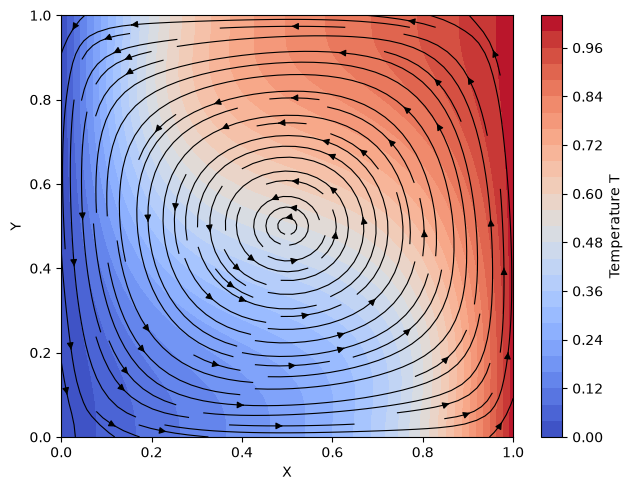

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Grid & Domain Setup
Nx, Ny = 41, 41
Lx, Ly = 1.0, 1.0
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

Ra = 100000
Pr = 0.1

# Fluid & Physical Properties
nu = 1e-3          # Kinematic viscosity
# alpha = 1e-3       # Thermal diffusivity (Prandtl number Pr = nu/alpha = 1.0)
alpha = nu/Pr
beta = 1e-2        # Thermal expansion coefficient
g = 9.81           # Gravity
rho = 1.0          # Reference density
mu = nu*rho

Tc = 0.0
# Th, Tc = 1.0, 0.0  # Hot and Cold wall temperatures
Th = (Ra*(mu**2))/((rho**2)*g*beta*(Ly**3)) + Tc
T0 = 0.5 * (Th + Tc)

# Time Integration & Stability
dt_visc = 0.25 / (nu * (1/dx**2 + 1/dy**2))
dt_therm = 0.25 / (alpha * (1/dx**2 + 1/dy**2))
dt = min(dt_visc, dt_therm)
nt = 1500
nit = 50  # PPE inner relaxation iterations

# Field Arrays
u = np.zeros((Ny, Nx))
v = np.zeros((Ny, Nx))
p = np.zeros((Ny, Nx))
T = np.full((Ny, Nx), T0)

# Temperature BC Initialization
#T[:, 0] = Th
#T[:, -1] = Tc
T[:, 0] = Tc
T[:, -1] = Th

# Main Time-Stepping Loop
for n in range(nt):
    un = u.copy()
    vn = v.copy()
    Tn = T.copy()

    # 1. Temperature Transport Update
    dTdx2 = (Tn[1:-1, 2:] - 2*Tn[1:-1, 1:-1] + Tn[1:-1, :-2]) / dx**2
    dTdy2 = (Tn[2:, 1:-1] - 2*Tn[1:-1, 1:-1] + Tn[:-2, 1:-1]) / dy**2
    dTdx = (Tn[1:-1, 2:] - Tn[1:-1, :-2]) / (2*dx)
    dTdy = (Tn[2:, 1:-1] - Tn[:-2, 1:-1]) / (2*dy)

    T[1:-1, 1:-1] = Tn[1:-1, 1:-1] + dt * (
        - un[1:-1, 1:-1] * dTdx - vn[1:-1, 1:-1] * dTdy + alpha * (dTdx2 + dTdy2)
    )

    # Temperature Boundary Conditions
    T[:, 0] = Tc                          # Left (Cold)
    T[:, -1] = Th                         # Right (Hot)
    T[0, :] = T[1, :]                     # Bottom (Adiabatic)
    T[-1, :] = T[-2, :]                   # Top (Adiabatic)

    # 2. Intermediate Velocity Prediction (u*, v*)
    u_star = un.copy()
    v_star = vn.copy()

    # u-momentum
    dudx2 = (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, :-2]) / dx**2
    dudy2 = (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[:-2, 1:-1]) / dy**2
    dudx = (un[1:-1, 2:] - un[1:-1, :-2]) / (2*dx)
    dudy = (un[2:, 1:-1] - un[:-2, 1:-1]) / (2*dy)

    u_star[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (
        - un[1:-1, 1:-1] * dudx - vn[1:-1, 1:-1] * dudy + nu * (dudx2 + dudy2)
    )

    # v-momentum (with Boussinesq Buoyancy Term)
    dvdx2 = (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, :-2]) / dx**2
    dvdy2 = (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[:-2, 1:-1]) / dy**2
    dvdx = (vn[1:-1, 2:] - vn[1:-1, :-2]) / (2*dx)
    dvdy = (vn[2:, 1:-1] - vn[:-2, 1:-1]) / (2*dy)

    buoyancy = g * beta * (T[1:-1, 1:-1] - T0)

    v_star[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (
        - un[1:-1, 1:-1] * dvdx - vn[1:-1, 1:-1] * dvdy + nu * (dvdx2 + dvdy2) + buoyancy
    )

    # Velocity BCs for u*, v* (No-slip walls)
    u_star[0, :] = u_star[-1, :] = u_star[:, 0] = u_star[:, -1] = 0.0
    v_star[0, :] = v_star[-1, :] = v_star[:, 0] = v_star[:, -1] = 0.0

    # 3. Divergence Source Term for PPE
    b = np.zeros((Ny, Nx))
    b[1:-1, 1:-1] = (rho / dt) * (
        (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx) +
        (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2*dy)
    )

    # 4. Pressure Poisson Solver
    for it in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (
            (pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2 +
            (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2 -
            b[1:-1, 1:-1] * dx**2 * dy**2
        ) / (2 * (dx**2 + dy**2))

        # Neumann BCs for Pressure
        p[:, -1] = p[:, -2]  # Right
        p[:, 0] = p[:, 1]    # Left
        p[0, :] = p[1, :]    # Bottom
        p[-1, :] = p[-2, :]  # Top

    # 5. Velocity Field Correction
    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - (dt / rho) * (
        (p[1:-1, 2:] - p[1:-1, :-2]) / (2*dx)
    )
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - (dt / rho) * (
        (p[2:, 1:-1] - p[:-2, 1:-1]) / (2*dy)
    )

    # No-slip BCs for u, v
    u[0, :] = u[-1, :] = u[:, 0] = u[:, -1] = 0.0
    v[0, :] = v[-1, :] = v[:, 0] = v[:, -1] = 0.0

# Visualization
X, Y = np.meshgrid(np.linspace(0, Lx, Nx), np.linspace(0, Ly, Ny))
plt.figure(figsize=(6.5, 5))
contour = plt.contourf(X, Y, T, 25, cmap='coolwarm')
plt.colorbar(contour, label='Temperature T')
plt.streamplot(X, Y, u, v, color='k', linewidth=0.8, density=1.2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.savefig("2D-buoyancy-driven-cavity-finite-difference.pdf")
plt.show()